# PaySim Anomaly Detection

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import KMeans
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

RANDOM_STATE = 42
DATASET_NAME = "PaySim"

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("paysim.csv")
df.head()

print("Shape:", df.shape)
print(df.info())
print("Missing values:", df.isnull().sum().sum())
print(df["isFraud"].value_counts())

# Drop unnecessary columns
if "isFlaggedFraud" in df.columns:
    df = df.drop(columns=["isFlaggedFraud"])

drop_cols = [col for col in ["nameOrig", "nameDest"] if col in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)

# Encode transaction type
df["type"] = df["type"].astype("category").cat.codes

# Rename target column
df = df.rename(columns={"isFraud": "Class"})
df.head()

Shape: (395819, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395819 entries, 0 to 395818
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            395819 non-null  int64  
 1   type            395819 non-null  object 
 2   amount          395818 non-null  float64
 3   nameOrig        395818 non-null  object 
 4   oldbalanceOrg   395818 non-null  float64
 5   newbalanceOrig  395818 non-null  float64
 6   nameDest        395818 non-null  object 
 7   oldbalanceDest  395818 non-null  float64
 8   newbalanceDest  395818 non-null  float64
 9   isFraud         395818 non-null  float64
 10  isFlaggedFraud  395818 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 33.2+ MB
None
Missing values: 9
isFraud
0.0    395614
1.0       204
Name: count, dtype: int64


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,Class
0,1,4,9839.64,170136.0,160296.36,0.0,0.0,0.0
1,1,4,1864.28,21249.0,19384.72,0.0,0.0,0.0
2,1,5,181.00,181.0,0.00,0.0,0.0,1.0
3,1,2,181.00,181.0,0.00,21182.0,0.0,1.0
4,1,4,11668.14,41554.0,29885.86,0.0,0.0,0.0


In [3]:
# =========================
# 2. DATASET SUMMARY
# =========================
total_samples = len(df)
fraud_samples = int(df["Class"].sum())
normal_samples = total_samples - fraud_samples
fraud_ratio = fraud_samples / total_samples

dataset_summary = pd.DataFrame([{
    "Dataset": DATASET_NAME,
    "Total Samples": total_samples,
    "Normal Samples": normal_samples,
    "Fraud Samples": fraud_samples,
    "Fraud Ratio": fraud_ratio,
    "Number of Features": df.shape[1] - 1
}])

print(dataset_summary)
dataset_summary.to_csv("paysim_dataset_summary.csv", index=False)


  Dataset  Total Samples  Normal Samples  Fraud Samples  Fraud Ratio  \
0  PaySim         395819          395615            204     0.000515   

   Number of Features  
0                   7  


In [4]:
# =========================
# 3. SPLIT DATA
# =========================
X = df.drop(columns=["Class"])
y = df["Class"]

X_normal = X[y == 0]
X_fraud = X[y == 1]

print("Normal samples:", len(X_normal))
print("Fraud samples:", len(X_fraud))

# Train only on normal transactions
X_train_normal, X_test_normal = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Test set = normal test + all fraud
X_test = pd.concat([X_test_normal, X_fraud], axis=0)
y_test = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_fraud))
])

print("Training set shape:", X_train_normal.shape)
print("Test set shape:", X_test.shape)
print("Fraud in test set:", np.sum(y_test))


Normal samples: 395614
Fraud samples: 204
Training set shape: (316491, 7)
Test set shape: (79327, 7)
Fraud in test set: 204.0


In [5]:
# =========================
# 4. SCALING
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

contamination = max(y.mean(), 1e-4)
print("Contamination:", contamination)


Contamination: 0.0005153883855711464


In [6]:
# =========================
# 5. CUSTOM MODELS
# =========================

class AutoencoderAnomalyDetector:
    def __init__(self, input_dim, encoding_dim=8, epochs=10, batch_size=1024, contamination=0.001):
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.contamination = contamination
        self.model = None
        self.threshold_ = None

    def build_model(self):
        input_layer = Input(shape=(self.input_dim,))
        encoded = Dense(16, activation="relu")(input_layer)
        encoded = Dense(self.encoding_dim, activation="relu")(encoded)
        decoded = Dense(16, activation="relu")(encoded)
        decoded = Dense(self.input_dim, activation="linear")(decoded)

        autoencoder = Model(inputs=input_layer, outputs=decoded)
        autoencoder.compile(optimizer="adam", loss="mse")
        return autoencoder

    def fit(self, X):
        self.model = self.build_model()

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=0
        )

        self.model.fit(
            X, X,
            epochs=self.epochs,
            batch_size=self.batch_size,
            shuffle=True,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0
        )

        reconstructions = self.model.predict(X, verbose=0)
        train_errors = np.mean(np.square(X - reconstructions), axis=1)

        self.threshold_ = np.percentile(train_errors, 100 * (1 - self.contamination))
        return self

    def decision_function(self, X):
        reconstructions = self.model.predict(X, verbose=0)
        errors = np.mean(np.square(X - reconstructions), axis=1)
        return -errors

    def predict(self, X):
        reconstructions = self.model.predict(X, verbose=0)
        errors = np.mean(np.square(X - reconstructions), axis=1)
        preds = np.where(errors > self.threshold_, -1, 1)
        return preds


class KMeansAnomalyDetector:
    def __init__(self, n_clusters=8, random_state=42, contamination=0.001):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.contamination = contamination
        self.model = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        self.threshold_ = None

    def fit(self, X):
        self.model.fit(X)
        distances = self._compute_min_distances(X)
        self.threshold_ = np.percentile(distances, 100 * (1 - self.contamination))
        return self

    def _compute_min_distances(self, X):
        distances = self.model.transform(X)
        min_distances = np.min(distances, axis=1)
        return min_distances

    def decision_function(self, X):
        distances = self._compute_min_distances(X)
        return -distances

    def predict(self, X):
        distances = self._compute_min_distances(X)
        preds = np.where(distances > self.threshold_, -1, 1)
        return preds


In [7]:
# =========================
# 6. HYPERPARAMETERS TABLE
# =========================
hyperparams_table = pd.DataFrame([
    {
        "Model": "Isolation Forest",
        "Hyperparameters": f"n_estimators=100, contamination={contamination:.6f}, random_state=42"
    },
    {
        "Model": "Tuned Isolation Forest",
        "Hyperparameters": f"n_estimators=300, max_samples=0.8, contamination={contamination:.6f}, random_state=42"
    },
    {
        "Model": "One-Class SVM",
        "Hyperparameters": "kernel='rbf', nu=0.01, gamma='scale'"
    },
    {
        "Model": "Local Outlier Factor",
        "Hyperparameters": f"n_neighbors=20, contamination={contamination:.6f}, novelty=True"
    },
    {
        "Model": "Autoencoder",
        "Hyperparameters": f"encoding_dim=8, epochs=10, batch_size=1024, threshold=percentile(1-contamination)"
    },
    {
        "Model": "Elliptic Envelope",
        "Hyperparameters": f"contamination={contamination:.6f}, random_state=42"
    },
    {
        "Model": "k-Means",
        "Hyperparameters": f"n_clusters=8, random_state=42, threshold=percentile(1-contamination)"
    }
])

print(hyperparams_table)
hyperparams_table.to_csv("paysim_hyperparameters.csv", index=False)

                    Model                                    Hyperparameters
0        Isolation Forest  n_estimators=100, contamination=0.000515, rand...
1  Tuned Isolation Forest  n_estimators=300, max_samples=0.8, contaminati...
2           One-Class SVM               kernel='rbf', nu=0.01, gamma='scale'
3    Local Outlier Factor  n_neighbors=20, contamination=0.000515, novelt...
4             Autoencoder  encoding_dim=8, epochs=10, batch_size=1024, th...
5       Elliptic Envelope            contamination=0.000515, random_state=42
6                 k-Means  n_clusters=8, random_state=42, threshold=perce...


In [8]:
# =========================
# 7. MODELS
# =========================
models = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=RANDOM_STATE
    ),
    "Tuned Isolation Forest": IsolationForest(
        n_estimators=300,
        max_samples=0.8,
        contamination=contamination,
        random_state=RANDOM_STATE
    ),
    "One-Class SVM": OneClassSVM(
        kernel="rbf",
        nu=0.01,
        gamma="scale"
    ),
    "Local Outlier Factor": LocalOutlierFactor(
        n_neighbors=20,
        contamination=contamination,
        novelty=True
    ),
    "Autoencoder": AutoencoderAnomalyDetector(
        input_dim=X_train_scaled.shape[1],
        encoding_dim=8,
        epochs=10,
        batch_size=1024,
        contamination=contamination
    ),
    "Elliptic Envelope": EllipticEnvelope(
        contamination=contamination,
        random_state=RANDOM_STATE
    ),
    "k-Means": KMeansAnomalyDetector(
        n_clusters=8,
        random_state=RANDOM_STATE,
        contamination=contamination
    )
}


In [9]:
# =========================
# 8. EVALUATION FUNCTION
# =========================
def evaluate_model(model, model_name, X_train, X_test, y_test, dataset_name):
    start_train = time.time()
    model.fit(X_train)
    train_time = time.time() - start_train

    start_test = time.time()
    preds_raw = model.predict(X_test)
    test_time = time.time() - start_test

    preds = np.where(preds_raw == -1, 1, 0)

    if hasattr(model, "decision_function"):
        raw_scores = model.decision_function(X_test)
        anomaly_scores = -raw_scores
    elif hasattr(model, "score_samples"):
        raw_scores = model.score_samples(X_test)
        anomaly_scores = -raw_scores
    else:
        anomaly_scores = preds.astype(float)

    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc_auc = roc_auc_score(y_test, anomaly_scores)
    pr_auc = average_precision_score(y_test, anomaly_scores)

    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    return {
        "Dataset": dataset_name,
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Train Time (s)": train_time,
        "Test Time (s)": test_time
    }, preds, anomaly_scores

In [10]:
# =========================
# 9. RUN ALL MODELS
# =========================
results = []
predictions_dict = {}
scores_dict = {}

for model_name, model in models.items():
    print(f"START: {model_name}")

    result, preds, scores = evaluate_model(
        model=model,
        model_name=model_name,
        X_train=X_train_scaled,
        X_test=X_test_scaled,
        y_test=y_test,
        dataset_name=DATASET_NAME
    )

    print(f"END: {model_name}")

    results.append(result)
    predictions_dict[model_name] = preds
    scores_dict[model_name] = scores

results_df = pd.DataFrame(results)
print(results_df)

results_df.to_csv("paysim_final_results.csv", index=False)

sorted_results = results_df.sort_values(by="F1-score", ascending=False)
print(sorted_results)


START: Isolation Forest
END: Isolation Forest
START: Tuned Isolation Forest
END: Tuned Isolation Forest
START: One-Class SVM
END: One-Class SVM
START: Local Outlier Factor
END: Local Outlier Factor
START: Autoencoder
END: Autoencoder
START: Elliptic Envelope
END: Elliptic Envelope
START: k-Means
END: k-Means
  Dataset                   Model  Precision    Recall  F1-score   ROC-AUC  \
0  PaySim        Isolation Forest   0.000000  0.000000  0.000000  0.736072   
1  PaySim  Tuned Isolation Forest   0.280000  0.068627  0.110236  0.779537   
2  PaySim           One-Class SVM   0.065854  0.264706  0.105469  0.778340   
3  PaySim    Local Outlier Factor   0.185185  0.049020  0.077519  0.689266   
4  PaySim             Autoencoder   0.491228  0.137255  0.214559  0.830210   
5  PaySim       Elliptic Envelope   0.041667  0.009804  0.015873  0.655052   
6  PaySim                 k-Means   0.157895  0.029412  0.049587  0.759828   

     PR-AUC     TN   FP   FN  TP  Train Time (s)  Test Time (s)  

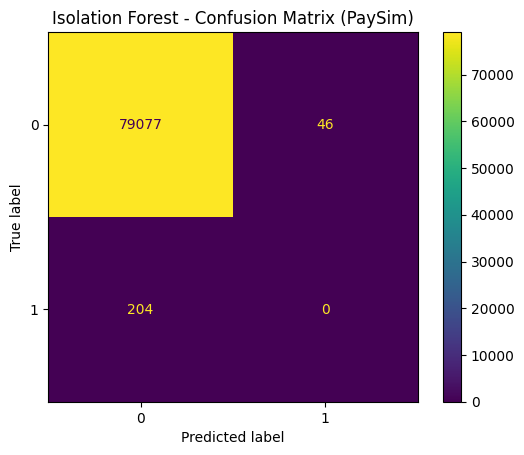

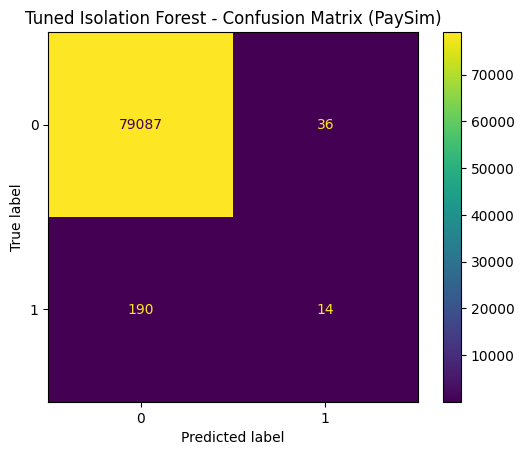

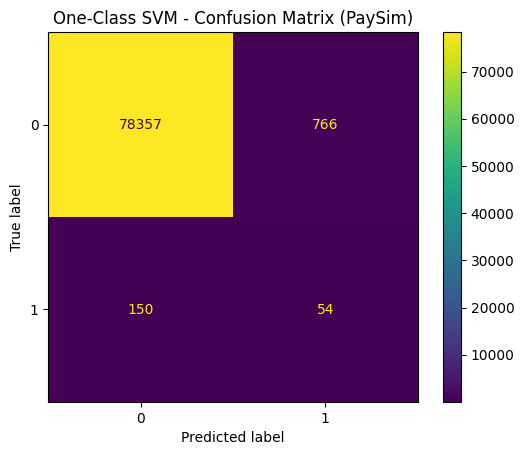

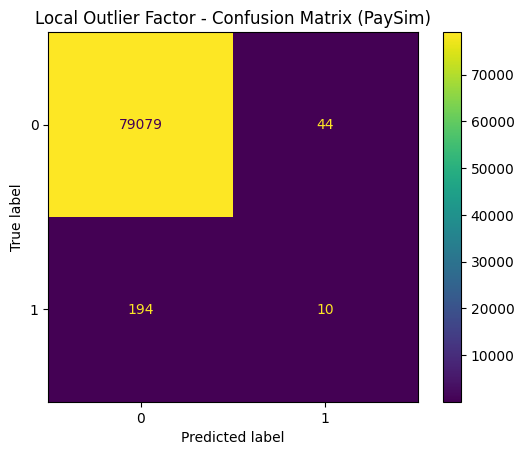

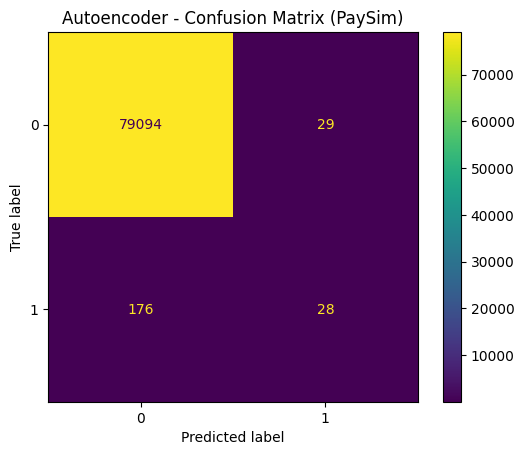

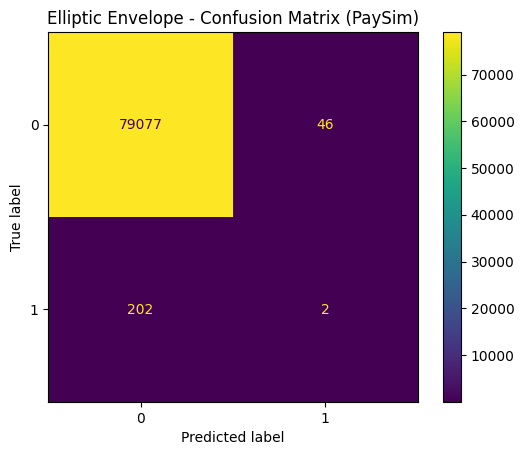

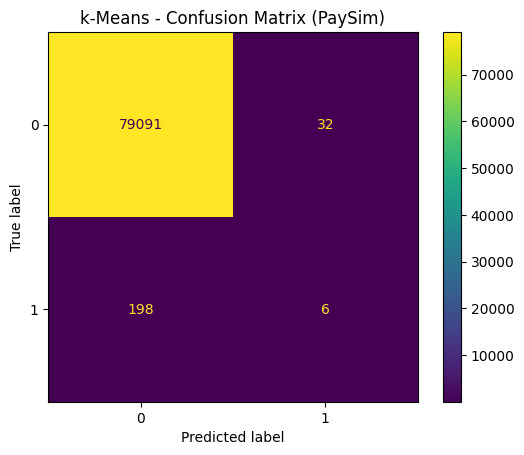

In [11]:
# =========================
# 10. CONFUSION MATRICES
# =========================
for model_name in models.keys():
    cm = confusion_matrix(y_test, predictions_dict[model_name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{model_name} - Confusion Matrix ({DATASET_NAME})")
    plt.show()

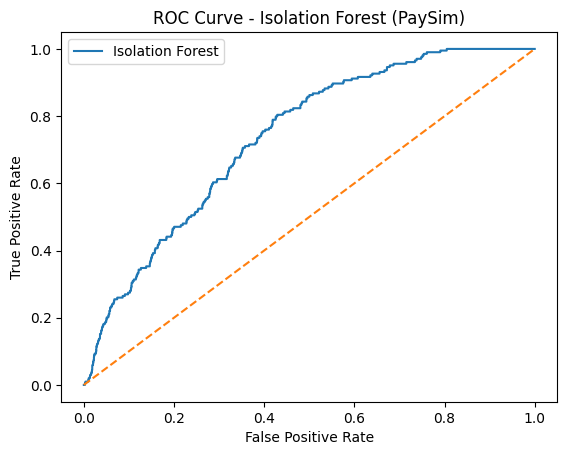

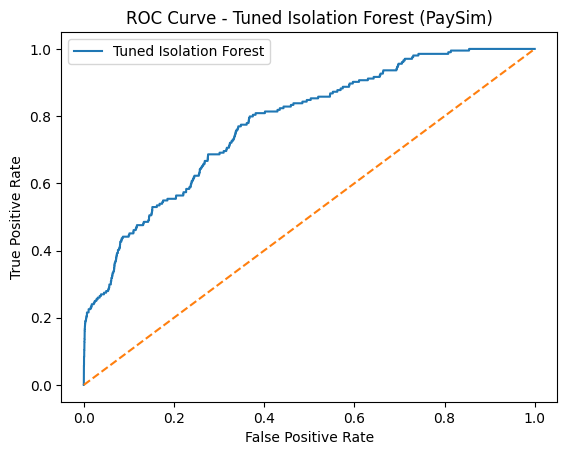

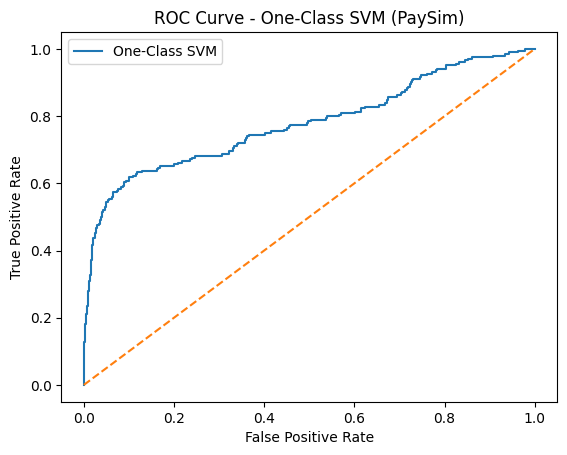

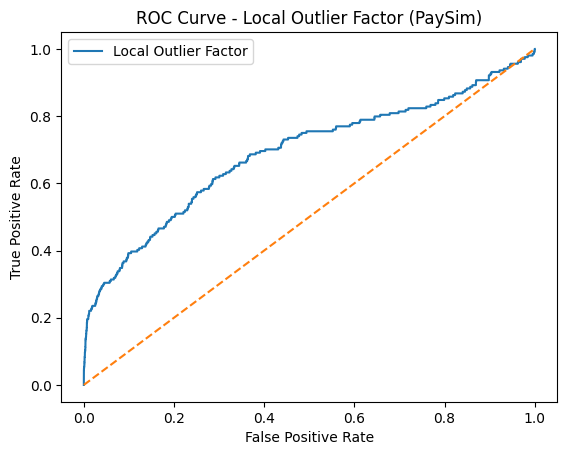

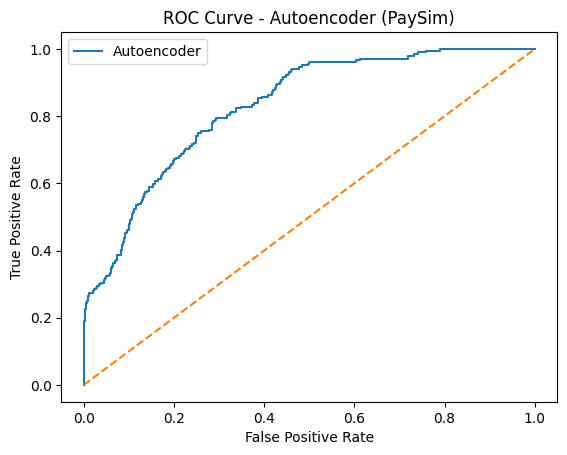

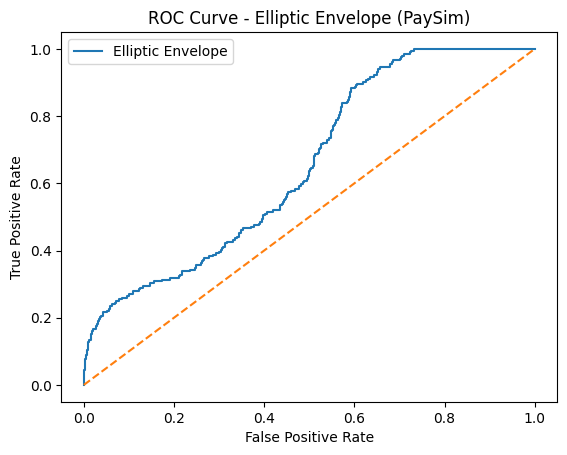

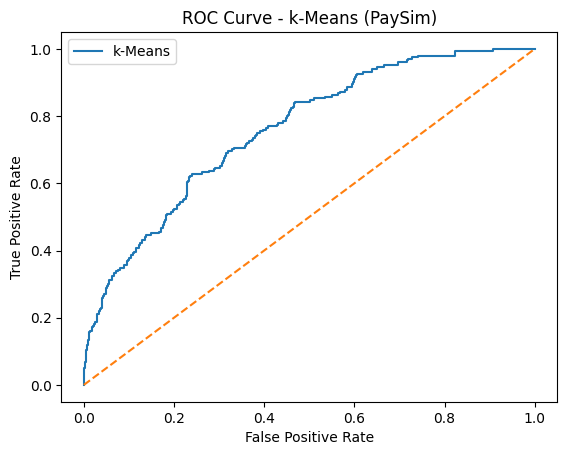

In [12]:
# =========================
# 11. ROC CURVES
# =========================
for model_name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, scores_dict[model_name])
    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name} ({DATASET_NAME})")
    plt.legend()
    plt.show()


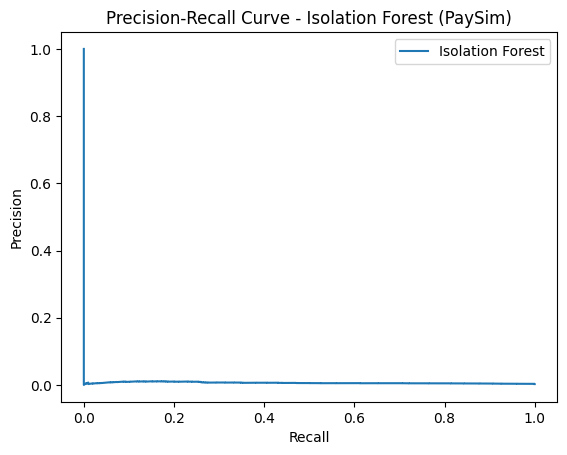

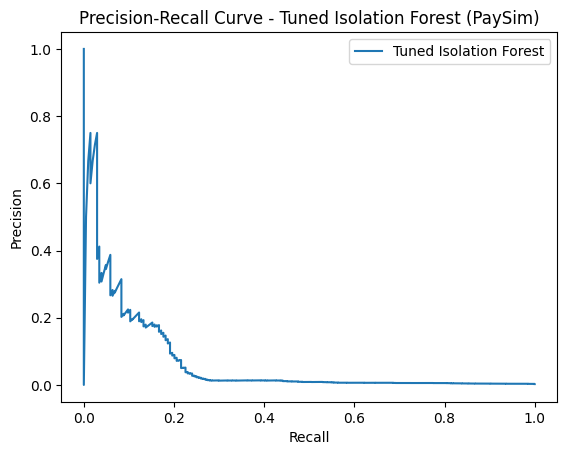

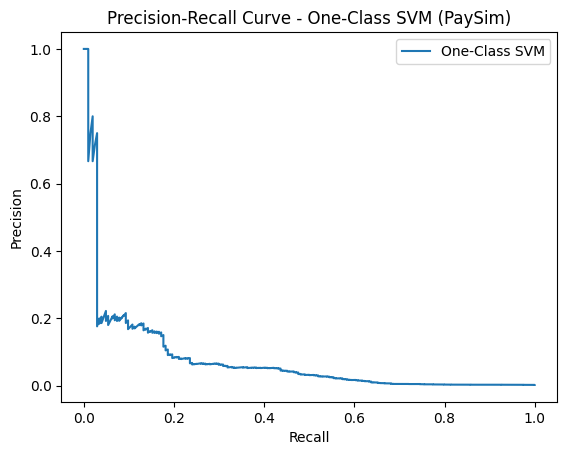

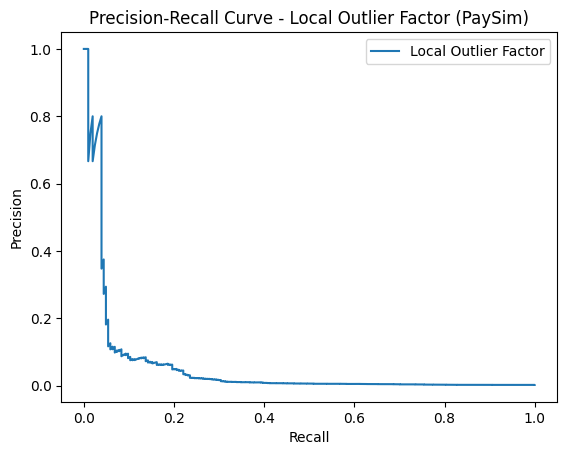

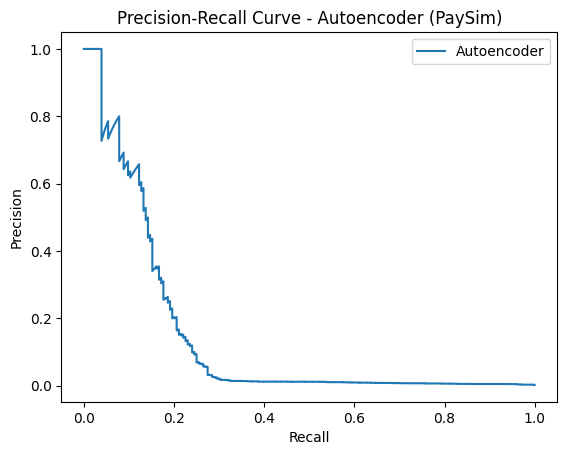

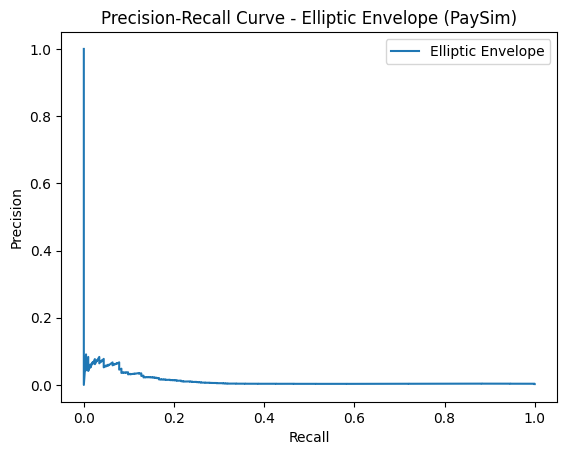

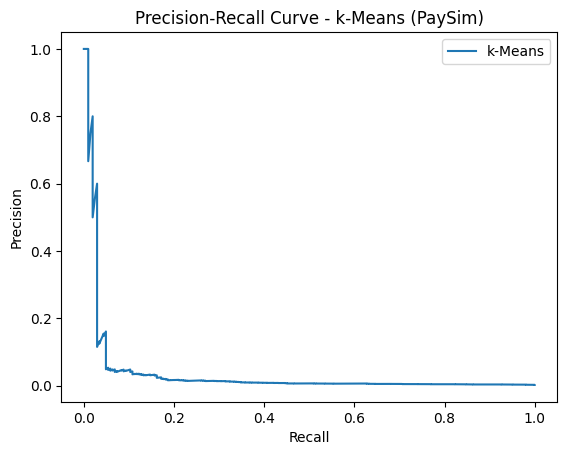

In [13]:
# =========================
# 12. PR CURVES
# =========================
for model_name in models.keys():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, scores_dict[model_name])
    plt.figure()
    plt.plot(recall_vals, precision_vals, label=f"{model_name}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {model_name} ({DATASET_NAME})")
    plt.legend()
    plt.show()

In [14]:
# =========================
# 13. BEST MODEL
# =========================
best_model_row = results_df.sort_values(by="F1-score", ascending=False).iloc[0]
print("\nBest model based on F1-score:")
print(best_model_row)


Best model based on F1-score:
Dataset                PaySim
Model             Autoencoder
Precision            0.491228
Recall               0.137255
F1-score             0.214559
ROC-AUC               0.83021
PR-AUC               0.143446
TN                      79094
FP                         29
FN                        176
TP                         28
Train Time (s)      36.333058
Test Time (s)        4.111083
Name: 4, dtype: object


In [15]:
comparison_df = results_df[[
    "Model",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "PR-AUC"
]].copy()

# сортируем по F1 (главная метрика)
comparison_df = comparison_df.sort_values(by="F1-score", ascending=False)

comparison_df

,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC
4,Autoencoder,0.491228,0.137255,0.214559,0.830210,0.143446
1,Tuned Isolation Forest,0.280000,0.068627,0.110236,0.779537,0.067072
2,One-Class SVM,0.065854,0.264706,0.105469,0.778340,0.076154
3,Local Outlier Factor,0.185185,0.049020,0.077519,0.689266,0.055299
6,k-Means,0.157895,0.029412,0.049587,0.759828,0.037275
5,Elliptic Envelope,0.041667,0.009804,0.015873,0.655052,0.012094
0,Isolation Forest,0.000000,0.000000,0.000000,0.736072,0.006243


In [16]:
comparison_df.to_csv("paysim_final_results.csv", index=False)

In [17]:
from google.colab import files
files.download("paysim_final_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>